# **Flood Mapping using Sentinel-2 Satellite Imagery**

### **Overview**
This project utilizes Sentinel-2 satellite imagery to detect flood layer. The approach leverages spectral indices to enhance water detection accuracy and distinguish between pre-flood and post-flood conditions.

### **Water Indices Used**
1. **NDWI (Normalized Difference Water Index)**  
   - Formula: **NDWI = (Green - NIR) / (Green + NIR)**  
   - Purpose: Enhances water body identification by utilizing the difference between green and near-infrared (NIR) reflectance.
.

### **Flood Detection Approach**
- **Pre-flood and post-flood images** are processed separately to compute NDWI.
- **Flooded areas** are detected by computing the difference:
  
  **Flood Map = Post-flood water mask - Pre-flood water mask**

### **Visualization**
- **Histograms** of NDWI are generated for pre-flood and post-flood conditions.
- The **flood map is overlaid on OSM base Map**, providing a clear visualization of flood extent.


# Install Libraries
## Uncomment below if using Github

In [ ]:
#!wget https://github.com/Munazaa/Flood-Mapping-Case/raw/main/requirements.txt

In [ ]:
#!pip install -r requirements.txt

In [1]:
!pip install rasterio numpy geopandas matplotlib shapely pillow contextily

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 27.4 MB/s eta 0:00:00


In [12]:
import rasterio
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from rasterio import features
from rasterio.features import shapes
from shapely.geometry import shape
from PIL import Image
import os
from rasterio import features
import geopandas as gpd
from rasterio.mask import mask
import zipfile
import contextily as ctx

In [ ]:
import digitalhub as dh

# Define project name
project_name = "docker-sentinel"

# Access the project
project = dh.get_or_create_project(project_name)

# List all artifacts in the project
artifacts = project.list_artifacts()

# Print available artifacts
artifact_names = [artifact.name for artifact in artifacts]
print("Available Artifacts in Project:", artifact_names)

In [ ]:
project = dh.get_or_create_project('docker-sentinel')

In [ ]:
af = project.get_artifact('sentinel1_GRD_preflood')
#af.download()

# Sentinel-2 Processing
## Please specify the folder path by accessing the artifacts (sentinel-2 data)
## Two folders named as: Sentinel-2(Pre-NDWI) , Sentinel-2(post-NDWI) 

In [ ]:
# Define pre-flood and post-flood folders
# Define pre-flood and post-flood folders
pre_flood_folder = "/content/Sentinel-2(Pre-NDWI)" 
post_flood_folder = "/content/Sentinel-2(post-NDWI)"
# Define AOI 
aoi_path = "/content/AOI.shp" #crop the Tile with AOI

Found 3 pre-flood images and 3 post-flood images.


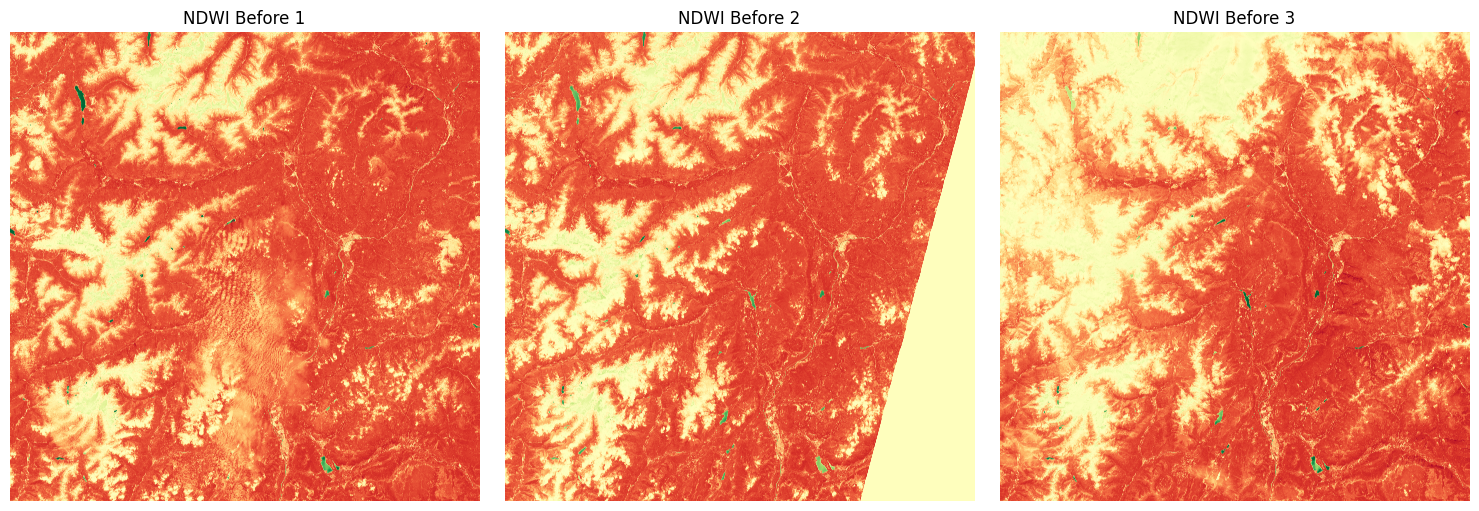

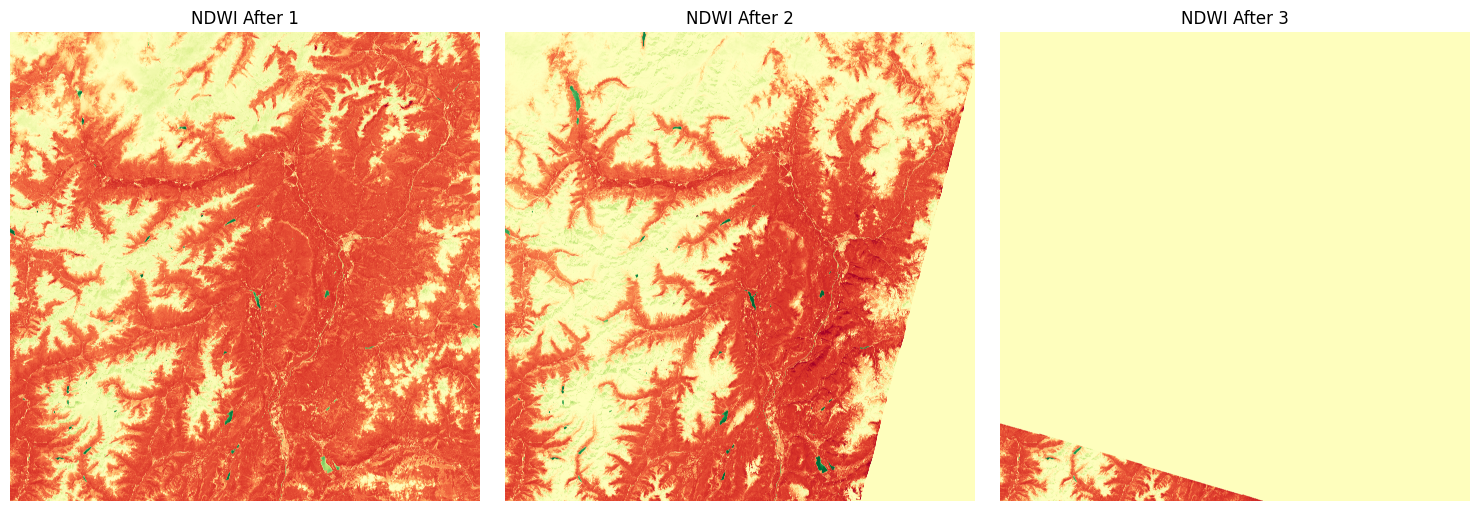

In [3]:
# Processing on the images

# Find all NDWI TIFF files in each folder
pre_flood_files = sorted(glob.glob(os.path.join(pre_flood_folder, "*.tif")))
post_flood_files = sorted(glob.glob(os.path.join(post_flood_folder, "*.tif")))

print(f"Found {len(pre_flood_files)} pre-flood images and {len(post_flood_files)} post-flood images.")

# Function to visualize NDWI images
def visualize_ndwi(files, title_prefix):
    num_images = len(files)
    cols = 3
    rows = (num_images // cols) + (num_images % cols > 0)  # Auto calculate rows

    fig, axs = plt.subplots(rows, cols, figsize=(15, 5 * rows))
    axs = axs.flatten()

    for i, file in enumerate(files):
        with rasterio.open(file) as src:
            ndwi = src.read(1)

        axs[i].imshow(ndwi, cmap='RdYlGn', vmin=-1, vmax=1)
        axs[i].set_title(f"{title_prefix} {i+1}")  # Simplified label
        axs[i].axis("off")

    # Hide any extra subplots
    for j in range(i+1, len(axs)):
        axs[j].axis("off")

    plt.tight_layout()
    plt.show()

# Visualize NDWI images before and after flood
visualize_ndwi(pre_flood_files, "NDWI Before")
visualize_ndwi(post_flood_files, "NDWI After")

In [16]:
# Find all NDWI TIFF files in each folder
pre_flood_files = sorted(glob.glob(os.path.join(pre_flood_folder, "*.tif")))
post_flood_files = sorted(glob.glob(os.path.join(post_flood_folder, "*.tif")))
# Function to compute the mean NDWI across multiple images
# Load AOI
aoi = gpd.read_file(aoi_path)
def compute_mean_ndwi(files):
    ndwi_stack = []

    for file in files:
        with rasterio.open(file) as src:
            # Reproject AOI to match the raster CRS
            aoi_projected = aoi.to_crs(src.crs)

            try:
                ndwi_cropped, _ = mask(src, aoi_projected.geometry, crop=True)
                ndwi_stack.append(ndwi_cropped[0])  # First band
            except ValueError as e:
                print(f"Skipping {file}: {e}")
                continue  # Skip files that don't overlap with AOI

    ndwi_stack = np.array(ndwi_stack)
    mean_ndwi = np.mean(ndwi_stack, axis=0)

    return mean_ndwi

# Compute mean NDWI for pre-flood and post-flood images
ndwi_pre = compute_mean_ndwi(pre_flood_files)
ndwi_post = compute_mean_ndwi(post_flood_files)


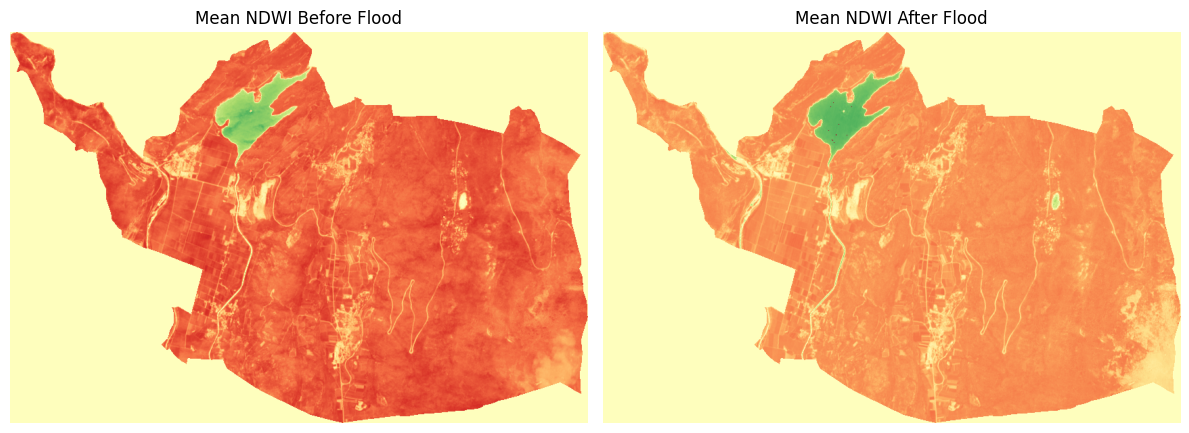

In [17]:
# Plot before and after NDWI side by side
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Before Flood
axs[0].imshow(ndwi_pre, cmap='RdYlGn', vmin=-1, vmax=1)
axs[0].set_title("Mean NDWI Before Flood")
axs[0].axis("off")

# After Flood
axs[1].imshow(ndwi_post, cmap='RdYlGn', vmin=-1, vmax=1)
axs[1].set_title("Mean NDWI After Flood")
axs[1].axis("off")

plt.tight_layout()
plt.show()

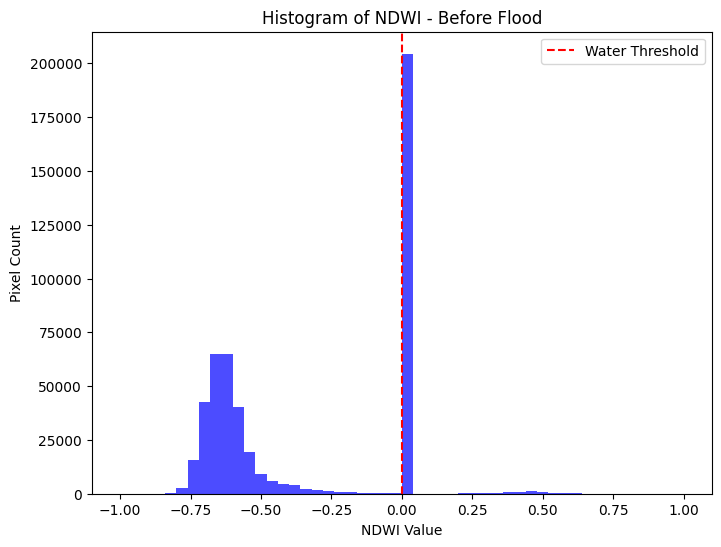

Water area in Before Flood: 1.35%


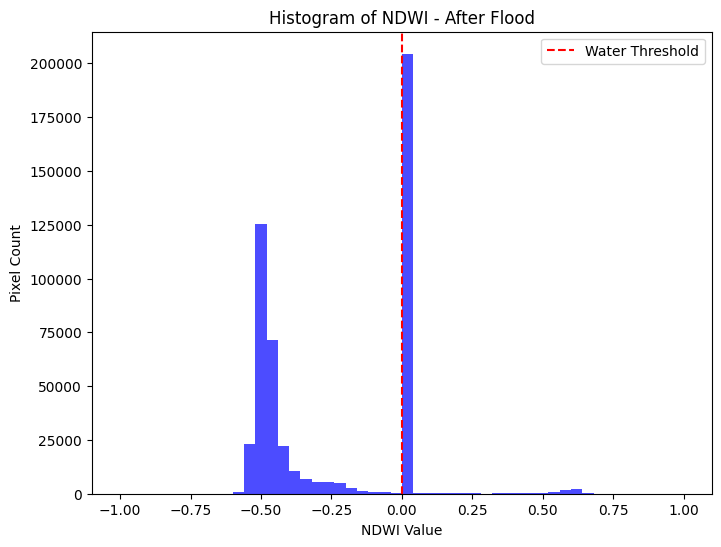

Water area in After Flood: 1.50%


In [18]:
# Function to calculate water pixels and plot histograms
def analyze_water(ndwi_array, title, threshold=0):
    # Classify water pixels based on NDWI threshold
    water_pixels = ndwi_array > threshold
    water_percentage = np.sum(water_pixels) / water_pixels.size * 100  # Calculate percentage

    # Plot histogram of NDWI values
    plt.figure(figsize=(8, 6))
    plt.hist(ndwi_array.flatten(), bins=50, range=(-1, 1), color='blue', alpha=0.7)
    plt.axvline(x=threshold, color='red', linestyle='--', label='Water Threshold')
    plt.xlabel("NDWI Value")
    plt.ylabel("Pixel Count")
    plt.title(f"Histogram of NDWI - {title}")
    plt.legend()
    plt.show()

    print(f"Water area in {title}: {water_percentage:.2f}%")

# Analyze water for both images
analyze_water(ndwi_pre, "Before Flood", threshold=0)
analyze_water(ndwi_post, "After Flood", threshold=0)


In [19]:
# Function to convert water pixels in NDWI (Post-Flood) to Shapefile
def convert_water_to_shapefile(ndwi_array, transform, output_shapefile, raster_crs, threshold=0):
    # Create a binary mask for water pixels based on the threshold
    water_pixels = ndwi_array > threshold

    # Convert binary mask to shapes (polygons)
    mask = water_pixels.astype(np.uint8)  # Convert boolean mask to uint8 for shapes function

    # Get the shapes (polygons) from the mask
    results = shapes(mask, mask=mask, transform=transform)

    # Extract geometries
    geometries = [shape(geom) for geom, _ in results]

    # Create a GeoDataFrame with the correct CRS (from the raster)
    gdf = gpd.GeoDataFrame({'geometry': geometries}, crs=raster_crs)

    # Save to shapefile
    gdf.to_file(output_shapefile)
    print(f"✅ Shapefile saved to {output_shapefile} with CRS: {raster_crs}")

# Load one of the post-flood NDWI images to get spatial reference (CRS & transform)
with rasterio.open(post_flood_files[0]) as src:
    transform = src.transform
    raster_crs = src.crs  # Get CRS from the first file

# Define output shapefile path
output_shapefile = "/content/sentinel-2_flood_layer.shp"

# Convert post-flood MNDWI water pixels to shapefile
convert_water_to_shapefile(ndwi_post, transform, output_shapefile, raster_crs, threshold=0) #threshold ranges between -1 to +1


✅ Shapefile saved to /content/drive/MyDrive/AIxPA (Demo Code)/Flood_layers-Munazza/sentinel-2v_flood_layer.shp with CRS: EPSG:32632


In [ ]:
#Flood Layer Visulization
# Load the exported flood shapefile
flood_gdf = gpd.read_file("/content/sentinel-2_flood_layer.shp")

# Reproject to Web Mercator for OSM basemap (EPSG:3857)
flood_gdf_web = flood_gdf.to_crs(epsg=3857)

# Plot
fig, ax = plt.subplots(figsize=(10, 10))
flood_gdf_web.plot(ax=ax, color='blue', alpha=0.5, edgecolor='black', linewidth=0.2)

# Add OSM basemap
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)

# Styling
ax.set_title("Flood Inundation")
ax.axis("off")
plt.tight_layout()
plt.show()
